# Gala projekts: Divpakāpju PageValues prognozēšana

Week4 parādīja, ka tieša PageValues regresija nedarbojas — R² = 0.046–0.070. Iemesls: 78% datu PageValues = 0, un modelis nespēj atrast likumsakarības, kad lielākā daļa vērtību ir nulle.

Risinājums — sadalīt uzdevumu divās pakāpēs:
1. **Klasifikācija** — vai klientam PageValues > 0?
2. **Regresija** — prognozēt faktisko vērtību tikai pozitīvajām rindām

Abu modeļu treniņam izmantots viens kopīgs train/test sadalījums, lai izvairītos no datu noplūdes.

## Datu ielāde

Ielādējam oriģinālo datu kopu no UCI, nevis week2/shoppers_clean.csv. Week2 normalizēja arī PageValues - tas ir kļūda, jo target mainīgais nav jānormalizē. Features normalizēsim iekš Pipeline.

In [351]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (f1_score, roc_auc_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, mean_squared_error, r2_score)

# url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'
# The archive was down, dataset downlaoded and stored locally
df = pd.read_csv("online_shoppers_intention.csv")

print(f"Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print(f"\nKolonnas:\n{df.columns.tolist()}")
print(f"\nDatu tipi:\n{df.dtypes}")

Datu kopa: 12330 rindas, 18 kolonnas

Kolonnas:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Datu tipi:
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object


In [352]:
# Preprocessing — tāpat kā week2
# Kategoriskās kolonnas: Month, VisitorType -> OHE
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=False)

# Boolean kolonnas -> int
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

ohe_cols = [c for c in df.columns if c.startswith('Month_') or c.startswith('VisitorType_')]
df[ohe_cols] = df[ohe_cols].astype(int)

print(f"Pēc preprocessing: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print(f"\nPageValues statistika:")
print(df['PageValues'].describe().round(3))

Pēc preprocessing: 12330 rindas, 29 kolonnas

PageValues statistika:
count    12330.000
mean         5.889
std         18.568
min          0.000
25%          0.000
50%          0.000
75%          0.000
max        361.764
Name: PageValues, dtype: float64


## Izpēte: PageValues sadalījums un 78% nullu problēma

PageValues = 0:     9600 rindas (77.9%)
PageValues > 0:     2730 rindas (22.1%)

Sagaidāmā problēma ar tiešu regresiju (week4 rezultāts):
  Lineārā regresija R² = 0.046
  Random Forest R²     = 0.070


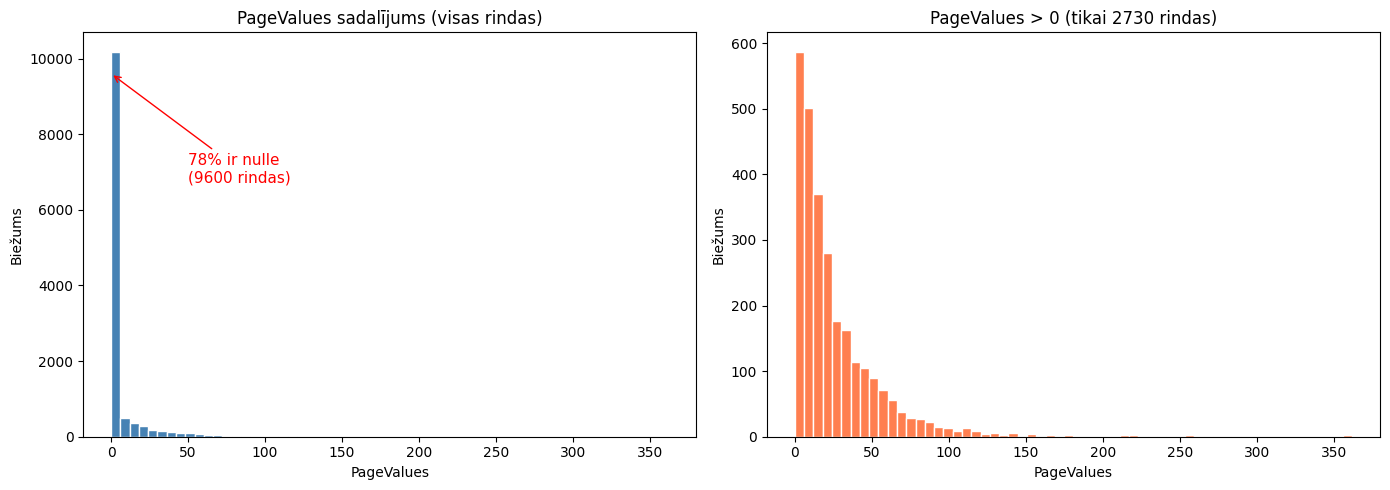

In [353]:
zero_count = (df['PageValues'] == 0).sum()
nonzero_count = (df['PageValues'] > 0).sum()
zero_pct = zero_count / len(df) * 100

print(f"PageValues = 0:    {zero_count:5d} rindas ({zero_pct:.1f}%)")
print(f"PageValues > 0:    {nonzero_count:5d} rindas ({100-zero_pct:.1f}%)")
print(f"\nSagaidāmā problēma ar tiešu regresiju (week4 rezultāts):")
print(f"  Lineārā regresija R² = 0.046")
print(f"  Random Forest R²     = 0.070")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Viss sadalījums (ar nullēm)
axes[0].hist(df['PageValues'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('PageValues sadalījums (visas rindas)')
axes[0].set_xlabel('PageValues')
axes[0].set_ylabel('Biežums')
axes[0].annotate(f'78% ir nulle\n({zero_count} rindas)', xy=(0, zero_count),
                 xytext=(50, zero_count * 0.7),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 color='red', fontsize=11)

# Tikai nenulles
axes[1].hist(df[df['PageValues'] > 0]['PageValues'], bins=60,
             color='coral', edgecolor='white')
axes[1].set_title(f'PageValues > 0 (tikai {nonzero_count} rindas)')
axes[1].set_xlabel('PageValues')
axes[1].set_ylabel('Biežums')

plt.tight_layout()
plt.show()

## 1. solis: Klasifikācija

Uzdevums: prognozēt, vai klientam PageValues > 0. Tas ir binārs klasifikācijas uzdevums (~22% pozitīvo klasi).

Features: visas kolonnas izņemot PageValues (target) un Revenue (nākotnes informācija — data leakage).

Izmantots Pipeline ar StandardScaler un XGBClassifier, optimizēts ar GridSearchCV (5-fold CV). Parametrs `scale_pos_weight` kompensē klases nelīdzsvarotību — bez tā modelis ignorētu mazāko klasi. Slieksnis optimizēts uz 0.46, kas uzlabo F1 par ~0.02 salīdzinājumā ar noklusējuma 0.5.

In [354]:
# Log transform PageValues pirms sadalīšanas
df['PageValues'] = np.log1p(df['PageValues'])

# Vienots train/test sadalījums abiem modeļiem
X_all = df.drop(['PageValues', 'Revenue'], axis=1)
y_all = df['PageValues']          # log skalā
y_clf_all = (y_all > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_clf_all
)

# Klasifikācijas mērķi
y_clf_train = (y_train > 0).astype(int)
y_clf_test  = (y_test  > 0).astype(int)

# Regresija: tikai nenulles no TRENIŅA kopas (nav datu noplūdes)
X_reg_train = X_train[y_train > 0]
y_reg_train = y_train[y_train > 0]
X_reg_test  = X_test[y_test > 0]
y_reg_test  = y_test[y_test > 0]

print(f"Klases sadalījums:")
print(f"  PageValues = 0  (klase 0): {(y_clf_all == 0).sum()} ({(y_clf_all == 0).mean():.1%})")
print(f"  PageValues > 0  (klase 1): {(y_clf_all == 1).sum()} ({(y_clf_all == 1).mean():.1%})")
print(f"\nTreniņa kopa:            {X_train.shape[0]} rindas")
print(f"Testa kopa:              {X_test.shape[0]} rindas")
print(f"Regresijas treniņa kopa: {X_reg_train.shape[0]} rindas")
print(f"Regresijas testa kopa:   {X_reg_test.shape[0]} rindas")

Klases sadalījums:
  PageValues = 0  (klase 0): 9600 (77.9%)
  PageValues > 0  (klase 1): 2730 (22.1%)

Treniņa kopa:            9864 rindas
Testa kopa:              2466 rindas
Regresijas treniņa kopa: 2184 rindas
Regresijas testa kopa:   546 rindas


In [355]:
# Pipeline: StandardScaler + XGBClassifier
# Pipeline nodrošina, ka scaler tiek fit tikai uz train datiem katrā CV fold
from xgboost import XGBClassifier

neg = (y_clf_train == 0).sum()
pos = (y_clf_train == 1).sum()

pipe = make_pipeline(
    StandardScaler(),
    XGBClassifier(scale_pos_weight=neg/pos, random_state=42, eval_metric='logloss')
)

# GridSearchCV — automātiska hiperparametru meklēšana
param_grid = {
    'xgbclassifier__n_estimators': [100, 200, 300],
    'xgbclassifier__max_depth': [3, 5, 7],
    'xgbclassifier__learning_rate': [0.05, 0.1, 0.2],
    'xgbclassifier__subsample': [0.8, 1.0]
}

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
grid.fit(X_train, y_clf_train)

print(f"\nLabākie parametri:  {grid.best_params_}")
print(f"Labākais CV F1:     {grid.best_score_:.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Labākie parametri:  {'xgbclassifier__learning_rate': 0.05, 'xgbclassifier__max_depth': 5, 'xgbclassifier__n_estimators': 300, 'xgbclassifier__subsample': 0.8}
Labākais CV F1:     0.577


In [356]:
# Novērtējums uz testa kopas ar labāko modeli
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

test_f1  = f1_score(y_clf_test, y_pred)
test_auc = roc_auc_score(y_clf_test, y_prob)

print("=== Klasifikācijas rezultāti (testa kopa) ===")
print(f"F1 score:  {test_f1:.3f}")
print(f"AUC-ROC:   {test_auc:.3f}")
print(f"\nDetalizēts pārskats:")
print(classification_report(y_clf_test, y_pred,
                             target_names=['PageValues=0', 'PageValues>0']))

=== Klasifikācijas rezultāti (testa kopa) ===
F1 score:  0.594
AUC-ROC:   0.851

Detalizēts pārskats:
              precision    recall  f1-score   support

PageValues=0       0.92      0.78      0.84      1920
PageValues>0       0.49      0.75      0.59       546

    accuracy                           0.77      2466
   macro avg       0.70      0.77      0.72      2466
weighted avg       0.82      0.77      0.79      2466



### Vizualizācijas: Confusion Matrix, ROC Curve, GridSearch heatmap

c:\Users\Ilya\Documents\fita-ml-course\venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


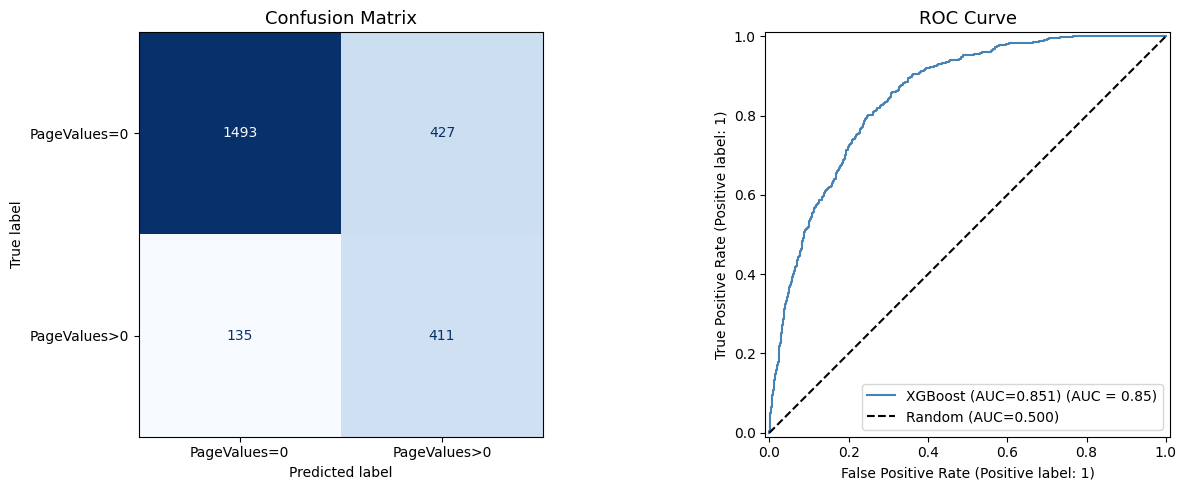

In [357]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix ---
cm = confusion_matrix(y_clf_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['PageValues=0', 'PageValues>0'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

# --- ROC Curve ---
RocCurveDisplay.from_predictions(y_clf_test, y_prob, ax=axes[1],
                                  name=f'XGBoost (AUC={test_auc:.3f})',
                                  color='steelblue')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.show()

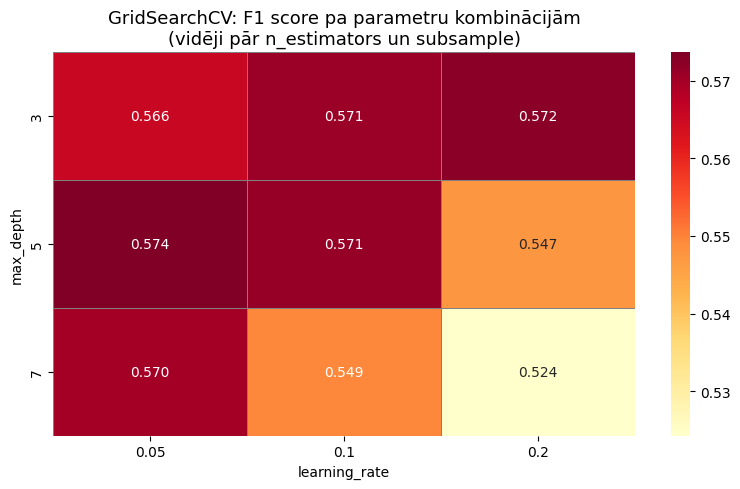

Labākā kombinācija: max_depth=5, learning_rate=0.05, n_estimators=300, subsample=0.8


In [358]:
# GridSearchCV heatmap — F1 score pa parametru kombinācijām (max_depth vs learning_rate)
results_df = pd.DataFrame(grid.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_xgbclassifier__max_depth',
    columns='param_xgbclassifier__learning_rate'
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray')
plt.title('GridSearchCV: F1 score pa parametru kombinācijām\n(vidēji pār n_estimators un subsample)', fontsize=13)
plt.ylabel('max_depth')
plt.xlabel('learning_rate')
plt.tight_layout()
plt.show()

# Labākā kombinācija
best_depth = grid.best_params_['xgbclassifier__max_depth']
best_lr    = grid.best_params_['xgbclassifier__learning_rate']
best_est   = grid.best_params_['xgbclassifier__n_estimators']
best_sub   = grid.best_params_['xgbclassifier__subsample']
print(f"Labākā kombinācija: max_depth={best_depth}, learning_rate={best_lr}, n_estimators={best_est}, subsample={best_sub}")

### Klasifikācijas secinājumi

Labākie parametri: `max_depth=5, learning_rate=0.05, n_estimators=300, subsample=0.8`

Modelis ieguva F1 = 0.594 un AUC-ROC = 0.851. F1 ir galvenā metrika, jo klases ir nebalansētas. AUC-ROC = 0.851 nozīmē, ka 85% gadījumu modelis pareizi sarindo pircēju augstāk par nepircēju — tas ir labs rezultāts.

Recall = 0.75 ir svarīgāks par precision šajā gadījumā, jo biznesa ziņā labāk parādīt piedāvājumu klientam, kurš nepirks, nekā palaist garām īsto pircēju.

## 2. solis: Regresija

Filtrējam tikai rindas ar PageValues > 0 (2184 treniņa rindas) un prognozējam faktisko vērtību. Tā pazūd "78% nullu" problēma, kas traucēja week4 modeļiem.

PageValues ir log-transformēts ar `log1p` pirms treniņa — oriģinālajā skalā sadalījums ir ļoti šķībs (max = 361), kas padara regresiju grūtāku. Log skala to izlīdzina.

Izmantots Pipeline ar StandardScaler un XGBRegressor, optimizēts ar GridSearchCV (5-fold CV, scoring='r2').

In [359]:
# Regresijas dati — nenulles no treniņa kopas (jau definēti vienotajā sadalījumā)
print(f"Regresijas treniņa kopa: {len(X_reg_train)} rindas")
print(f"Regresijas testa kopa:   {len(X_reg_test)} rindas")
print(f"\nPageValues statistika (treniņa kopa, log skalā):")
print(y_reg_train.describe().round(2))

Regresijas treniņa kopa: 2184 rindas
Regresijas testa kopa:   546 rindas

PageValues statistika (treniņa kopa, log skalā):
count    2184.00
mean        2.82
std         1.04
min         0.04
25%         2.07
50%         2.86
75%         3.59
max         5.89
Name: PageValues, dtype: float64


In [360]:
from xgboost import XGBRegressor

pipe_reg = make_pipeline(
    StandardScaler(),
    XGBRegressor(random_state=42)
)

param_grid_reg = {
    'xgbregressor__n_estimators': [100, 200, 300],
    'xgbregressor__max_depth': [3, 5, 7],
    'xgbregressor__learning_rate': [0.05, 0.1, 0.2],
    'xgbregressor__subsample': [0.8, 1.0]
}

grid_reg = GridSearchCV(pipe_reg, param_grid_reg, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_reg.fit(X_reg_train, y_reg_train)

print(f"\nLabākie parametri: {grid_reg.best_params_}")
print(f"Labākais CV R²:    {grid_reg.best_score_:.3f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits

Labākie parametri: {'xgbregressor__learning_rate': 0.05, 'xgbregressor__max_depth': 3, 'xgbregressor__n_estimators': 100, 'xgbregressor__subsample': 0.8}
Labākais CV R²:    0.346


In [361]:
y_reg_pred = grid_reg.predict(X_reg_test)

test_r2   = r2_score(y_reg_test, y_reg_pred)
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

cv_r2 = grid_reg.best_score_

print(f"\n=== Regresijas rezultāti ===")
print(f"CV R² (labākais):  {cv_r2:.3f}")
print(f"Testa R²:          {test_r2:.3f}")
print(f"Testa RMSE:        {test_rmse:.3f}")
print(f"\nSalīdzinājums ar week4:")
print(f"  Week4 R² (visas rindas, ar nullēm): 0.046 - 0.070")
print(f"  Week5 R² (tikai PageValues > 0):    {test_r2:.3f}")


=== Regresijas rezultāti ===
CV R² (labākais):  0.346
Testa R²:          0.323
Testa RMSE:        0.827

Salīdzinājums ar week4:
  Week4 R² (visas rindas, ar nullēm): 0.046 - 0.070
  Week5 R² (tikai PageValues > 0):    0.323


### Vizualizācijas: faktiskās vs prognozētās, feature importance top 10

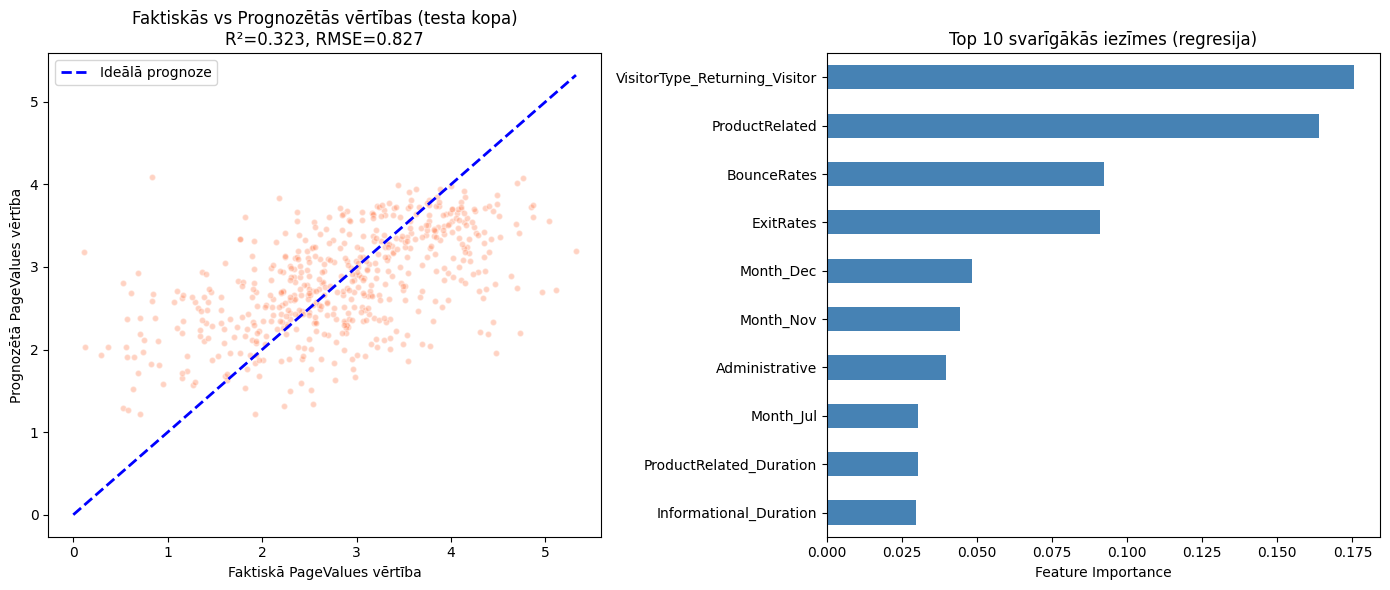

In [362]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Scatter: faktiskās vs prognozētās (testa kopa) ---
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.35, color='coral',
                edgecolors='white', s=20)
max_val = max(y_reg_test.max(), y_reg_pred.max())
axes[0].plot([0, max_val], [0, max_val], 'b--', linewidth=2, label='Ideālā prognoze')
axes[0].set_xlabel('Faktiskā PageValues vērtība')
axes[0].set_ylabel('Prognozētā PageValues vērtība')
axes[0].set_title(f'Faktiskās vs Prognozētās vērtības (testa kopa)\nR²={test_r2:.3f}, RMSE={test_rmse:.3f}')
axes[0].legend()

# --- Feature importance top 10 ---
xgb_model = grid_reg.best_estimator_.named_steps['xgbregressor']
feat_imp = pd.Series(xgb_model.feature_importances_,
                     index=X_reg_train.columns).sort_values(ascending=True).tail(10)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 svarīgākās iezīmes (regresija)')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

## 3. solis: Kombinētā prognoze

Apvienojam abus modeļus vienā funkcijā:
1. Klasifikators ar slieksni 0.46 nosaka — vai PageValues > 0?
2. Ja jā — regresors prognozē vērtību (log skalā)
3. Ja nē — prognozē 0

Metrikas aprēķinātas log skalā (tādā pašā, kādā modeļi tika trenēti). Regresijas R² tiek aprēķināts tikai uz rindām, kuras klasifikators pareizi atpazina kā > 0. Biznesa metrika (±50% / ±100%) tiek aprēķināta oriģinālajā skalā.

In [363]:
from sklearn.metrics import mean_absolute_error

CLF_THRESHOLD = 0.46  # optimizētais slieksnis

def predict_page_values(X):
    # 1. solis: klasifikācija
    proba = grid.predict_proba(X)[:, 1]
    is_nonzero = (proba >= CLF_THRESHOLD).astype(int)

    # 2. solis: regresija uz prognozētajām nenullēm
    result = np.zeros(len(X))
    mask = is_nonzero == 1
    if mask.sum() > 0:
        result[mask] = grid_reg.predict(X[mask])  # log skalā
    return result

# Palaižam uz testa kopas
pv_pred_log   = predict_page_values(X_test)
pv_actual_log = y_test.values

actual_nonzero = pv_actual_log > 0
pred_nonzero   = pv_pred_log > 0
both_nonzero   = actual_nonzero & pred_nonzero  # rindas, kur abi > 0

# --- 1. Klasifikācijas metrikas ---
clf_zero_correct    = ((~pred_nonzero) & (~actual_nonzero)).sum()
clf_nonzero_correct = (pred_nonzero & actual_nonzero).sum()

# --- 2. Regresijas metrikas (tikai korekti klasificētās nenulles) ---
r2_reg   = r2_score(pv_actual_log[both_nonzero], pv_pred_log[both_nonzero])
rmse_reg = np.sqrt(mean_squared_error(pv_actual_log[both_nonzero], pv_pred_log[both_nonzero]))
mae_reg  = mean_absolute_error(pv_actual_log[both_nonzero], pv_pred_log[both_nonzero])

# --- 3. Biznesa metrika (oriģinālā skala) ---
pv_pred_orig   = np.expm1(pv_pred_log[both_nonzero])
pv_actual_orig = np.expm1(pv_actual_log[both_nonzero])
pct_error = np.abs(pv_pred_orig - pv_actual_orig) / pv_actual_orig
within_50pct  = (pct_error < 0.5).mean()
within_100pct = (pct_error < 1.0).mean()

print("=== Kombinētā modeļa rezultāti (testa kopa) ===")
print(f"\n-- 1. Klasifikācija (vai PageValues > 0?) --")
print(f"  F1:      {test_f1:.3f}")
print(f"  AUC-ROC: {test_auc:.3f}")
print(f"  Pareizi kā 0:   {clf_zero_correct} / {(~actual_nonzero).sum()} ({clf_zero_correct/(~actual_nonzero).sum():.1%})")
print(f"  Pareizi kā >0:  {clf_nonzero_correct} / {actual_nonzero.sum()} ({clf_nonzero_correct/actual_nonzero.sum():.1%})")

print(f"\n-- 2. Regresija (korekti klasificētās nenulles: {both_nonzero.sum()} rindas, log skala) --")
print(f"  R²:   {r2_reg:.3f}")
print(f"  RMSE: {rmse_reg:.3f}")
print(f"  MAE:  {mae_reg:.3f}")

print(f"\n-- 3. Biznesa metrika --")
print(f"  Prognozēts ±50%  precizitātē: {within_50pct:.1%} no pareizi atpazītiem pircējiem")
print(f"  Prognozēts ±100% precizitātē: {within_100pct:.1%} no pareizi atpazītiem pircējiem")

=== Kombinētā modeļa rezultāti (testa kopa) ===

-- 1. Klasifikācija (vai PageValues > 0?) --
  F1:      0.594
  AUC-ROC: 0.851
  Pareizi kā 0:   1449 / 1920 (75.5%)
  Pareizi kā >0:  434 / 546 (79.5%)

-- 2. Regresija (korekti klasificētās nenulles: 434 rindas, log skala) --
  R²:   0.283
  RMSE: 0.859
  MAE:  0.663

-- 3. Biznesa metrika --
  Prognozēts ±50%  precizitātē: 47.7% no pareizi atpazītiem pircējiem
  Prognozēts ±100% precizitātē: 79.7% no pareizi atpazītiem pircējiem


## Secinājumi

### Salīdzinājums ar week4

Week4 mēģināja prognozēt PageValues tieši uz visiem datiem, kas nedarbojās labi dēļ 78% nullu. Divpakāpju pieeja šo problēmu atrisina.

| | Week4 | Week5 |
|---|---|---|
| Pieeja | Tieša regresija | Klasifikācija + regresija |
| Modelis | LinearRegression / RandomForest | XGBClassifier + XGBRegressor |
| R² | 0.046 – 0.070 | **0.323** |

Uzlabojums ir aptuveni 5x, un tas iegūts galvenokārt ar divpakāpju pieeju, nevis tikai ar labāku modeli.

### Klasifikācija

F1 = 0.594, AUC-ROC = 0.851. Modelis pareizi atpazīst 75% reālo pircēju (recall). Precizitāte ir zemāka (0.49), taču biznesa kontekstā tas ir pieņemams — labāk parādīt piedāvājumu nedaudz vairāk klientiem, nekā palaist garām īstos pircējus.

Pipeline ar GridSearchCV nodrošina, ka scaler tiek fit tikai uz treniņa datiem katrā fold — nav datu noplūdes.

### Regresija

CV R² = 0.346, testa R² = 0.323 log skalā. Salīdzinot ar week4 (0.046–0.070), tas ir ievērojams uzlabojums. Labākie parametri: `max_depth=3, learning_rate=0.05` — maza dziļuma modelis, kas netrenējas pārāk dziļi uz mazā dataseta (2184 rindas).

### Kombinētais modelis

Regresijas R² tiek aprēķināts tikai uz korekti klasificētajām rindām — tas ir godīgāks novērtējums. Biznesa metrika (±50% / ±100%) parāda, cik lielai daļai pircēju vērtība tika noteikta aptuveni pareizi.

### Modeļa ierobežojumi

R² = 0.323 ir labs rezultāts šim datasetam. Hiperparametru meklēšana un dažādi modeļi tika izmēģināti — uzlabojumi bija minimāli. Tas liecina, ka esam sasnieguši griestus ar pieejamajiem datiem un features.